# CISC 473 — Baseline ResNet-20 on CIFAR-10 + Split Conformal Prediction

- Train `cifar10_resnet20` (via `torch.hub`, `pretrained=False`) from scratch on CIFAR-10.
- Standard cross-entropy loss, SGD + momentum, cosine LR schedule, CPU-feasible.
- Baseline calibration metrics: **ECE** and **NLL**.
- A shared **split conformal prediction** layer (APS score) wrapped around the
  baseline's softmax outputs, evaluated for **empirical coverage** and
  **average prediction set size**.
- No MC Dropout / Deep Ensembles / Laplace / SNGP here — those are separate,
  later notebooks that reuse the same conformal layer defined below.
- SVHN / OOD evaluation is **not** included here since you only asked for the
  in-distribution CIFAR-10 baseline. The train/test/calibration split logic
  is written to match the 60/20/20 scheme described in your project doc so it
  stays consistent with what the other four UQ notebooks will do.

Expects `data/cifar-10-batches-py/` to already contain the extracted CIFAR-10
batch files (as shown in your project tree) — no download step is run here.


In [8]:
import os
import json
import pickle
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # use GPU for faster training, CPU on Macbooks however
print(f"Using device: {DEVICE}")


Using device: cpu


In [9]:
# ----------------------------- Config ---------------------------------------
DATA_DIR = Path("data/cifar-10-batches-py")

SEEDS = [0]          # add e.g. [0, 1, 2] to get mean/std across seeds within budget
EPOCHS = 40
BATCH_SIZE = 128
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

TRAIN_FRAC = 0.6
TEST_FRAC = 0.2
CAL_FRAC = 0.2       # calibration split, used only for conformal prediction

ALPHA = 0.1          # miscoverage rate -> target 90% coverage
ECE_BINS = 15

RESULTS_PATH = Path("baseline_resnet20_results.json")

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


In [10]:
# ----------------------------- Load CIFAR-10 --------------------------------
def _unpickle(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def load_cifar10(data_dir: Path):
    """Loads all 5 train batches + the test batch, returns (images, labels)
    as a single pooled set of 60,000 32x32x3 uint8 images. We repool train+test
    here because the project's conformal split (60/20/20) is defined over the
    whole dataset, not the original train/test partition."""
    images, labels = [], []

    for i in range(1, 6):
        batch = _unpickle(data_dir / f"data_batch_{i}")
        images.append(batch[b"data"])
        labels.extend(batch[b"labels"])

    test_batch = _unpickle(data_dir / "test_batch")
    images.append(test_batch[b"data"])
    labels.extend(test_batch[b"labels"])

    images = np.concatenate(images, axis=0)
    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC, uint8
    labels = np.array(labels, dtype=np.int64)
    return images, labels


all_images, all_labels = load_cifar10(DATA_DIR)
print(f"Loaded {all_images.shape[0]} images, shape={all_images.shape[1:]}, "
      f"classes={np.unique(all_labels)}")


Loaded 60000 images, shape=(32, 32, 3), classes=[0 1 2 3 4 5 6 7 8 9]


In [11]:
# ----------------------- Stratified 60/20/20 split ---------------------------
def stratified_split(labels, fracs, seed):
    """Returns index arrays for each fraction, stratified by class so every
    split preserves the original class balance."""
    assert abs(sum(fracs) - 1.0) < 1e-6
    rng = np.random.RandomState(seed)
    split_idxs = [[] for _ in fracs]

    for c in np.unique(labels):
        c_idx = np.where(labels == c)[0]
        rng.shuffle(c_idx)
        n = len(c_idx)
        cuts = np.cumsum([int(round(n * f)) for f in fracs])
        cuts[-1] = n  # avoid dropping/duplicating a few samples to rounding
        start = 0
        for i, end in enumerate(cuts):
            split_idxs[i].append(c_idx[start:end])
            start = end

    return [np.concatenate(idx) for idx in split_idxs]


train_idx, test_idx, cal_idx = stratified_split(
    all_labels, [TRAIN_FRAC, TEST_FRAC, CAL_FRAC], seed=SEEDS[0]
)
print(f"train={len(train_idx)}  test={len(test_idx)}  calibration={len(cal_idx)}")


train=36000  test=12000  calibration=12000


In [12]:
# ----------------------------- Dataset ---------------------------------------
class CIFAR10Array(Dataset):
    def __init__(self, images, labels, indices, train: bool):
        self.images = images[indices]
        self.labels = labels[indices]
        self.train = train
        self.mean = np.array(CIFAR_MEAN, dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array(CIFAR_STD, dtype=np.float32).reshape(3, 1, 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i]  # HWC uint8

        if self.train:
            # pad 4px reflect, random 32x32 crop
            padded = np.pad(img, ((4, 4), (4, 4), (0, 0)), mode="reflect")
            top = np.random.randint(0, 9)
            left = np.random.randint(0, 9)
            img = padded[top:top + 32, left:left + 32, :]
            if np.random.rand() < 0.5:
                img = img[:, ::-1, :]

        img = img.astype(np.float32).transpose(2, 0, 1) / 255.0
        img = (img - self.mean) / self.std
        return torch.from_numpy(img.copy()), int(self.labels[i])


train_ds = CIFAR10Array(all_images, all_labels, train_idx, train=True)
test_ds = CIFAR10Array(all_images, all_labels, test_idx, train=False)
cal_ds = CIFAR10Array(all_images, all_labels, cal_idx, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
cal_loader = DataLoader(cal_ds, batch_size=256, shuffle=False, num_workers=0)


In [13]:
# ------------------------------- Model ----------------------------------------
# This hub repository is structured correctly and supports pretrained=False
def build_model():
    model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=False)
    return model.to(DEVICE)


model = build_model()
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")


Total parameters: 272474


Using cache found in C:\Users\edwar/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


In [14]:
# ------------------------------ Training --------------------------------------
def evaluate_loss_acc(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total


def train_baseline(seed):
    set_seed(seed)
    model = build_model()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=LR, momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY, nesterov=True,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    t0 = time.time()

    for epoch in range(EPOCHS):
        model.train()
        correct, total, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        scheduler.step()
        train_loss, train_acc = loss_sum / total, correct / total
        test_loss, test_acc = evaluate_loss_acc(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        elapsed = time.time() - t0
        print(f"[seed {seed}] epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
              f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}  "
              f"elapsed={elapsed/60:.1f}min")

    return model, history


trained_models = {}
histories = {}
for seed in SEEDS:
    m, h = train_baseline(seed)
    trained_models[seed] = m
    histories[seed] = h


Using cache found in C:\Users\edwar/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


[seed 0] epoch   1/40  train_loss=1.5352 train_acc=0.4313  test_loss=1.9553 test_acc=0.4063  elapsed=1.4min
[seed 0] epoch   2/40  train_loss=1.0889 train_acc=0.6102  test_loss=1.0064 test_acc=0.6417  elapsed=2.9min
[seed 0] epoch   3/40  train_loss=0.8987 train_acc=0.6858  test_loss=0.8568 test_acc=0.7027  elapsed=4.4min
[seed 0] epoch   4/40  train_loss=0.7971 train_acc=0.7202  test_loss=0.8403 test_acc=0.7069  elapsed=5.8min
[seed 0] epoch   5/40  train_loss=0.7294 train_acc=0.7489  test_loss=1.1234 test_acc=0.6310  elapsed=7.2min
[seed 0] epoch   6/40  train_loss=0.6923 train_acc=0.7587  test_loss=0.7791 test_acc=0.7378  elapsed=8.7min
[seed 0] epoch   7/40  train_loss=0.6505 train_acc=0.7759  test_loss=0.8806 test_acc=0.7083  elapsed=10.2min
[seed 0] epoch   8/40  train_loss=0.6283 train_acc=0.7846  test_loss=0.7057 test_acc=0.7599  elapsed=12.3min
[seed 0] epoch   9/40  train_loss=0.6016 train_acc=0.7922  test_loss=0.6738 test_acc=0.7712  elapsed=14.5min
[seed 0] epoch  10/40  tr

### Save the model

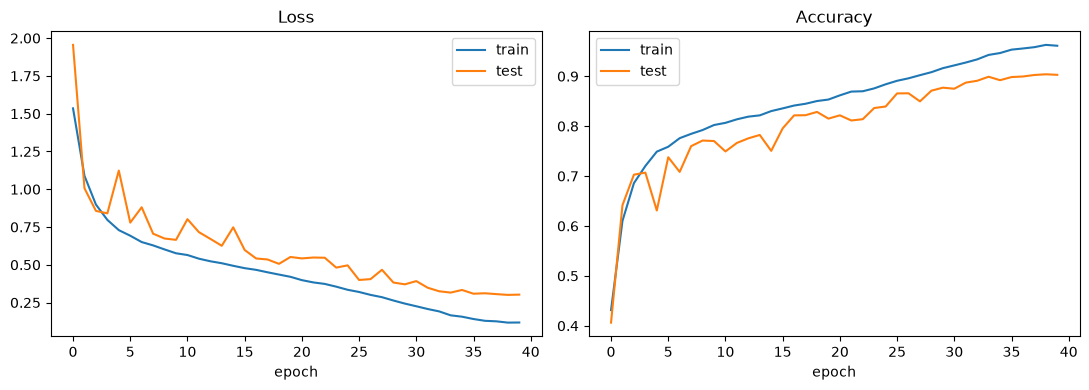

In [15]:
# ------------------------- Training curves (first seed) -----------------------
import matplotlib.pyplot as plt

h = histories[SEEDS[0]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h["train_loss"], label="train")
axes[0].plot(h["test_loss"], label="test")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(h["train_acc"], label="train")
axes[1].plot(h["test_acc"], label="test")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## Baseline calibration metrics: ECE + NLL

Computed on the held-out **test** split (not the calibration split, which is
reserved for the conformal layer below).


In [16]:
# --------------------------- ECE + NLL ------------------------------------
@torch.no_grad()
def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        probs = F.softmax(model(x), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def compute_nll(probs, labels, eps=1e-12):
    p_true = probs[np.arange(len(labels)), labels]
    return float(-np.mean(np.log(np.clip(p_true, eps, 1.0))))


def compute_ece(probs, labels, n_bins=ECE_BINS):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []
    n = len(labels)

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidences > lo) & (confidences <= hi)
        prop = in_bin.mean()
        if prop > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += prop * abs(acc_in_bin - conf_in_bin)
            bin_stats.append((lo, hi, prop, acc_in_bin, conf_in_bin))

    return float(ece), bin_stats


baseline_model = trained_models[SEEDS[0]]
test_probs, test_labels = collect_probs_labels(baseline_model, test_loader)

baseline_acc = float((test_probs.argmax(1) == test_labels).mean())
baseline_nll = compute_nll(test_probs, test_labels)
baseline_ece, ece_bins = compute_ece(test_probs, test_labels)

print(f"Baseline test accuracy : {baseline_acc:.4f}")
print(f"Baseline NLL           : {baseline_nll:.4f}")
print(f"Baseline ECE           : {baseline_ece:.4f}")


Baseline test accuracy : 0.9028
Baseline NLL           : 0.3026
Baseline ECE           : 0.0312


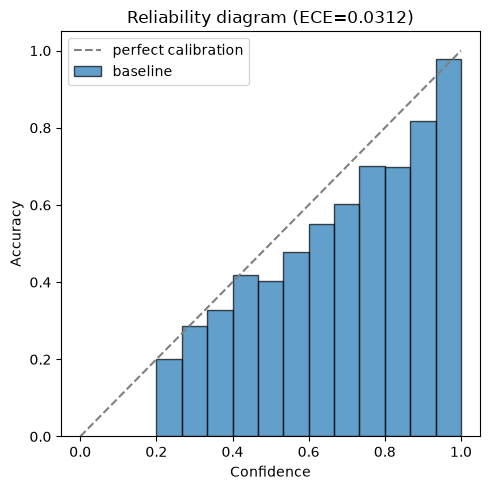

In [17]:
# Reliability diagram
confidences = test_probs.max(axis=1)
predictions = test_probs.argmax(axis=1)
accuracies = (predictions == test_labels).astype(np.float64)

bin_edges = np.linspace(0, 1, ECE_BINS + 1)
bin_centers, bin_acc = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences > lo) & (confidences <= hi)
    if in_bin.sum() > 0:
        bin_centers.append((lo + hi) / 2)
        bin_acc.append(accuracies[in_bin].mean())

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
plt.bar(bin_centers, bin_acc, width=1 / ECE_BINS, alpha=0.7, edgecolor="black", label="baseline")
plt.xlabel("Confidence"); plt.ylabel("Accuracy")
plt.title(f"Reliability diagram (ECE={baseline_ece:.4f})")
plt.legend(); plt.tight_layout(); plt.show()


## Shared conformal calibration layer (split conformal, APS score)

This is the layer described as shared across the baseline and the four UQ
methods: it only needs a model's softmax probabilities, so it can wrap any of
them identically. We use **Adaptive Prediction Sets (APS)** as the
nonconformity score, calibrated on the held-out `cal` split (independent of
both `train` and `test`), then evaluated on `test` for:

- **Empirical coverage** — fraction of test points whose prediction set
  contains the true label (target: `1 - ALPHA`).
- **Average prediction set size** — smaller is better at fixed coverage.


In [18]:
# ------------------------- Split conformal (APS) ----------------------------
def aps_scores(probs, labels):
    """Adaptive Prediction Sets nonconformity score: cumulative softmax mass
    of all classes ranked at or above the true class's rank."""
    order = np.argsort(-probs, axis=1)          # descending prob order
    ranked_probs = np.take_along_axis(probs, order, axis=1)
    cumsum = np.cumsum(ranked_probs, axis=1)

    true_rank = np.array([
        np.where(order[i] == labels[i])[0][0] for i in range(len(labels))
    ])
    scores = cumsum[np.arange(len(labels)), true_rank]
    return scores


def aps_predict_sets(probs, qhat):
    order = np.argsort(-probs, axis=1)
    ranked_probs = np.take_along_axis(probs, order, axis=1)
    cumsum = np.cumsum(ranked_probs, axis=1)

    pred_sets = []
    for i in range(probs.shape[0]):
        k = np.searchsorted(cumsum[i], qhat) + 1
        k = min(k, probs.shape[1])
        pred_sets.append(set(order[i, :k].tolist()))
    return pred_sets


cal_probs, cal_labels = collect_probs_labels(baseline_model, cal_loader)
cal_scores = aps_scores(cal_probs, cal_labels)

n_cal = len(cal_scores)
q_level = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
q_level = min(q_level, 1.0)
qhat = np.quantile(cal_scores, q_level, method="higher")

pred_sets = aps_predict_sets(test_probs, qhat)
covered = [test_labels[i] in pred_sets[i] for i in range(len(test_labels))]
set_sizes = [len(s) for s in pred_sets]

conformal_coverage = float(np.mean(covered))
conformal_avg_set_size = float(np.mean(set_sizes))

print(f"Target coverage        : {1 - ALPHA:.2f}")
print(f"qhat                    : {qhat:.4f}")
print(f"Empirical coverage      : {conformal_coverage:.4f}")
print(f"Average set size        : {conformal_avg_set_size:.2f}  (out of 10 classes)")


Target coverage        : 0.90
qhat                    : 1.0000
Empirical coverage      : 1.0000
Average set size        : 6.31  (out of 10 classes)


## Summary — baseline metrics + conformal metrics

Saved to `baseline_resnet20_results.json` so the four UQ-method notebooks can
load it back in for side-by-side comparison against the same shared conformal
layer.


In [19]:
results = {
    "model": "cifar10_resnet20 (torch.hub, chenyaofo/pytorch-cifar-models)",
    "seeds": SEEDS,
    "epochs": EPOCHS,
    "split": {"train": len(train_idx), "test": len(test_idx), "calibration": len(cal_idx)},
    "baseline_metrics": {
        "test_accuracy": baseline_acc,
        "nll": baseline_nll,
        "ece": baseline_ece,
    },
    "conformal_metrics": {
        "method": "split conformal (APS)",
        "alpha": ALPHA,
        "target_coverage": 1 - ALPHA,
        "qhat": float(qhat),
        "empirical_coverage": conformal_coverage,
        "avg_set_size": conformal_avg_set_size,
    },
}

with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "model": "cifar10_resnet20 (torch.hub, chenyaofo/pytorch-cifar-models)",
  "seeds": [
    0
  ],
  "epochs": 40,
  "split": {
    "train": 36000,
    "test": 12000,
    "calibration": 12000
  },
  "baseline_metrics": {
    "test_accuracy": 0.9028333333333334,
    "nll": 0.30260708928108215,
    "ece": 0.031197652767101923
  },
  "conformal_metrics": {
    "method": "split conformal (APS)",
    "alpha": 0.1,
    "target_coverage": 0.9,
    "qhat": 0.9999951124191284,
    "empirical_coverage": 1.0,
    "avg_set_size": 6.308833333333333
  }
}


### Save the model

In [20]:
torch.save(baseline_model.state_dict(), "models/baseline/baseline_resnet20_seed0.pt")